
# **Assignment: Implementation of Logistic Regression and LinearSVM** <br>
#### Submitted by: Group 4
#### Members:
- Canete, Mariane Charisse
- Gaca, Karl Michael
- Galorio, Vincent
- Lapad, Gabriella Mae
- Llesis, Hannah
- Maling, Eumir
- Sevilla, Emmanuel

# **I. About the Dataset**

The `fruit_data_with_colors.xlsx` dataset contains 59 observations with 7 variables, consisting of both numerical and categorical features. The target variable appears to be fruit_name, which includes four fruit classes: `apple`, `mandarin`, `orange`, and `lemon`.

From the structure of the dataset, the following observations were made:

- No missing values were found, so no data cleaning for nulls is needed.
- Numerical features include: `mass`, `width`, `height`, `color_score`.
- Categorical features include: `fruit_name` and `fruit_subtype`.
- `fruit_label` is redundant since it encodes the same information as `fruit_name`, so one should be dropped.
- `fruit_subtype` may be excluded depending on whether fine-grained classification is needed.
- Feature scaling is required due to different value ranges, especially for kNN and SVM.
- The dataset is small, so careful model evaluation is needed to avoid overfitting.

In [ ]:
#Import necessary library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')

In [ ]:
# Load the Excel file
df = pd.read_excel('/content/fruit_data_with_colors.xlsx')

# Display basic info about the dataset
df.head()

,fruit_label,fruit_name,fruit_subtype,mass,width,height,color_score
0,1,apple,granny_smith,192,8.4,7.3,0.55
1,1,apple,granny_smith,180,8.0,6.8,0.59
2,1,apple,granny_smith,176,7.4,7.2,0.60
3,2,mandarin,mandarin,86,6.2,4.7,0.80
4,2,mandarin,mandarin,84,6.0,4.6,0.79


In [ ]:
# Check the columns to understand the data structure
df.columns

In [ ]:
# Summary Statistics of the dataset
df.describe()

,fruit_label,mass,width,height,color_score
count,59.000000,59.000000,59.000000,59.000000,59.000000
mean,2.542373,163.118644,7.105085,7.693220,0.762881
std,1.208048,55.018832,0.816938,1.361017,0.076857
min,1.000000,76.000000,5.800000,4.000000,0.550000
25%,1.000000,140.000000,6.600000,7.200000,0.720000
50%,3.000000,158.000000,7.200000,7.600000,0.750000
75%,4.000000,177.000000,7.500000,8.200000,0.810000
max,4.000000,362.000000,9.600000,10.500000,0.930000


In [ ]:
# Check what fruits are in the dataset
df['fruit_name'].unique()

array(['apple', 'mandarin', 'orange', 'lemon'], dtype=object)

In [ ]:
#Check counts of each fruit
df["fruit_name"].value_counts()

,count
fruit_name,
apple,19
orange,19
lemon,16
mandarin,5


## **1. Histograms**

Histograms are plotted to examine the frequency distribution of each numeric feature (mass, width, height, color_score) per fruit class, as well as the overall class distribution.

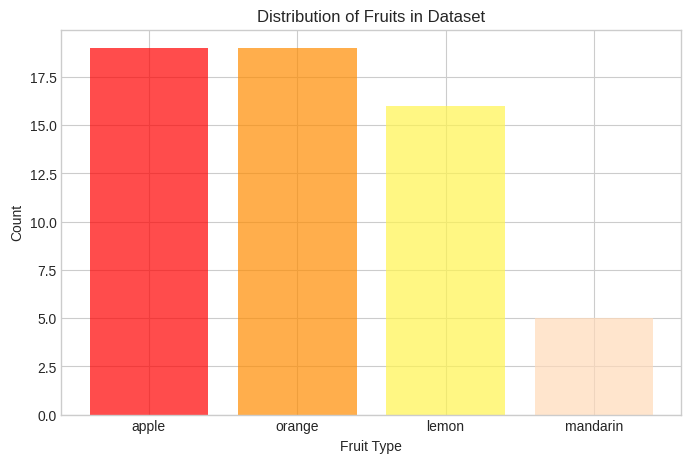

In [ ]:
fruit_color_map = {
    'apple': 'red',
    'mandarin': 'peachpuff',
    'orange': 'darkorange',
    'lemon': '#FFF44F'
}

fruit_counts = df["fruit_name"].value_counts()

colors = [fruit_color_map[fruit] for fruit in fruit_counts.index]

plt.figure(figsize=(8,5))
plt.bar(fruit_counts.index, fruit_counts.values, color=colors, alpha = 0.7)

plt.title("Distribution of Fruits in Dataset")
plt.xlabel("Fruit Type")
plt.ylabel("Count")

plt.show()

The dataset is mostly balanced between `apple` and `orange` (19 samples each), slightly lower for `lemon` (16 samples), and highly underrepresented for `mandarin` (5 samples), indicating a **mild class imbalance**.

In [ ]:
#Defining numeric columns
numeric_features = ["mass", "width", "height", "color_score"]

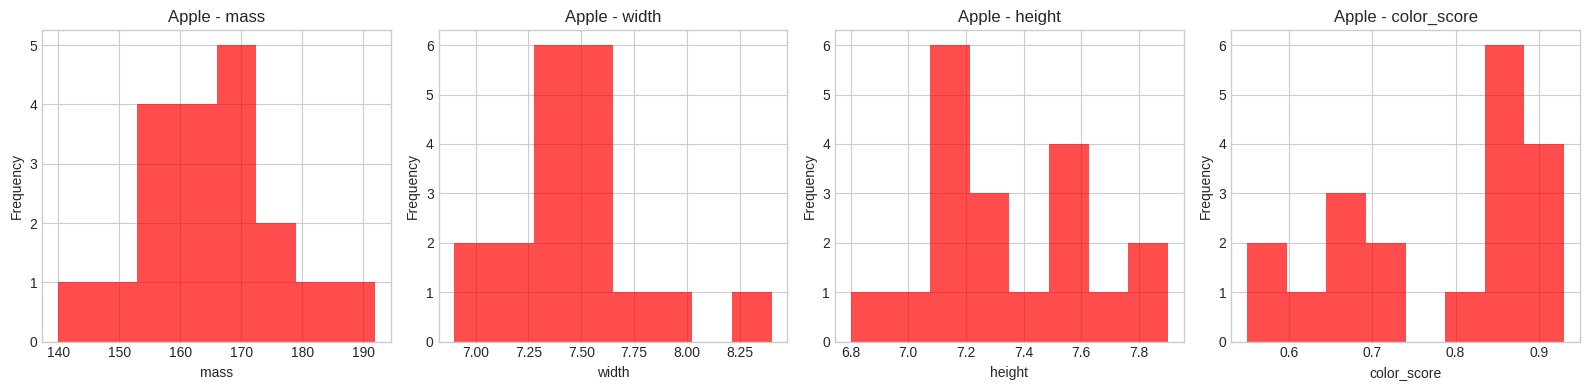

In [ ]:
# cCreate Histograms of Numeric Columns for Apple
subset = df[df["fruit_name"] == "apple"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, feature in enumerate(numeric_features):
    axes[i].hist(subset[feature], bins=8, color="red", alpha=0.7)
    axes[i].set_title(f"Apple - {feature}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

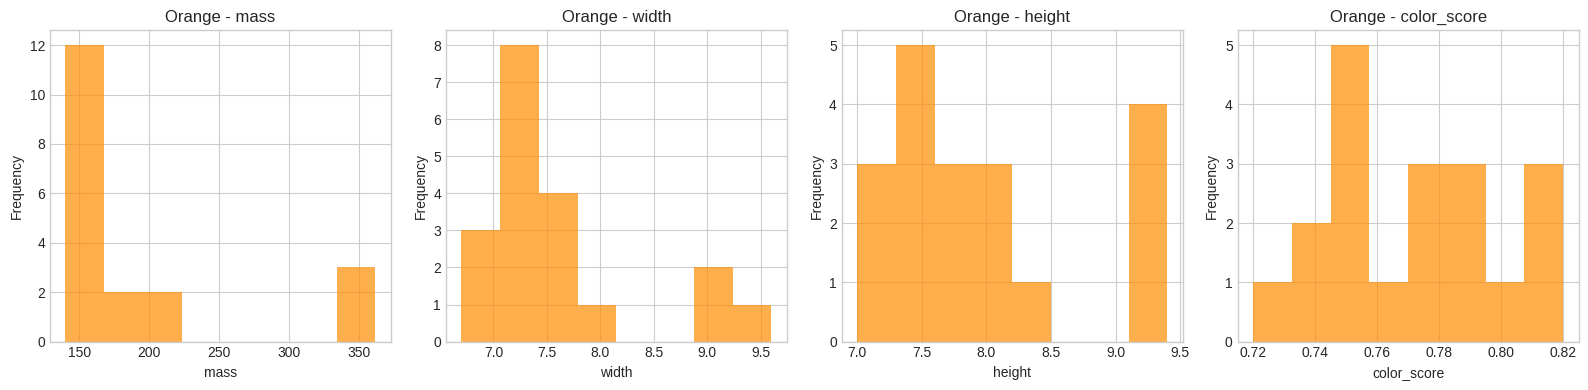

In [ ]:
# Create Histograms of Numeric Columns Distribution for Orange
subset = df[df["fruit_name"] == "orange"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, feature in enumerate(numeric_features):
    axes[i].hist(subset[feature], bins=8, color="darkorange", alpha=0.7)
    axes[i].set_title(f"Orange - {feature}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

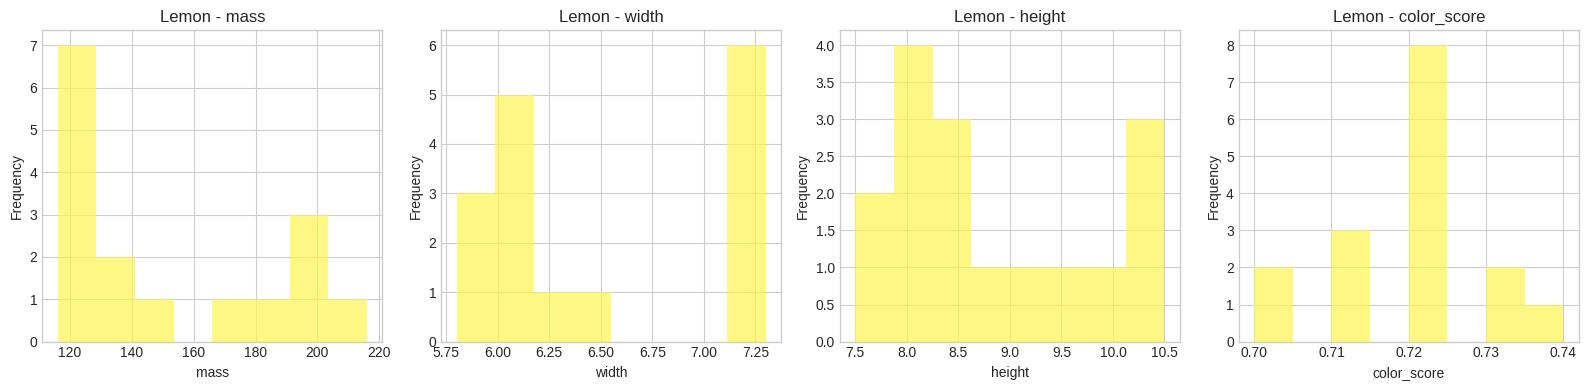

In [ ]:
# Create Histograms of Numeric Columns Distribution for Lemon
subset = df[df["fruit_name"] == "lemon"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, feature in enumerate(numeric_features):
    axes[i].hist(subset[feature], bins=8, color="#FFF44F", alpha=0.7)
    axes[i].set_title(f"Lemon - {feature}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

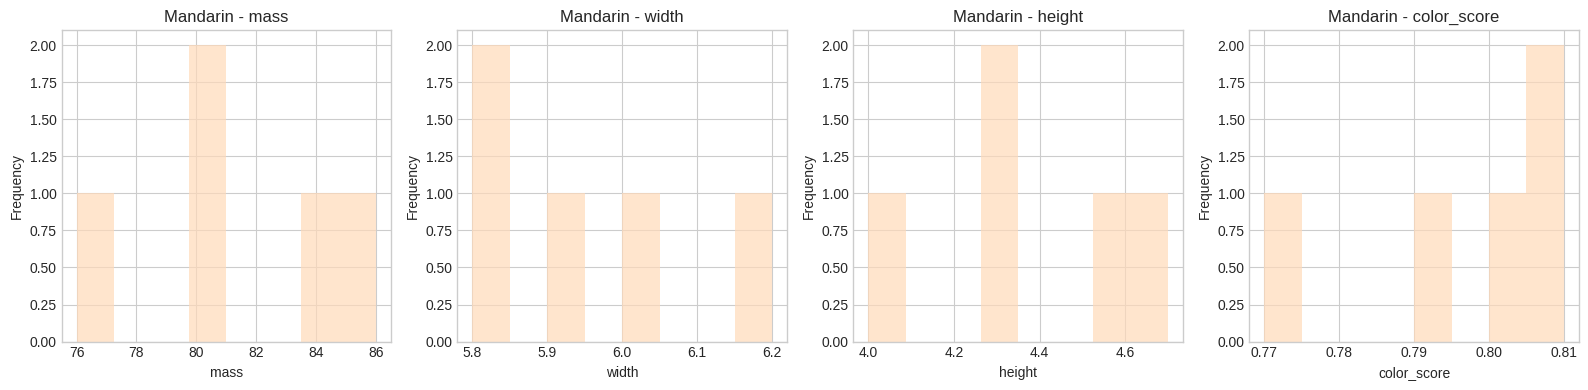

In [ ]:
# Create Histograms of Numeric Columns Distribution for Mandarin
subset = df[df["fruit_name"] == "mandarin"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, feature in enumerate(numeric_features):
    axes[i].hist(subset[feature], bins=8, color="peachpuff", alpha=0.7)
    axes[i].set_title(f"Mandarin - {feature}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

The dataset shows mild class imbalance apple and orange are well-represented (19 each), while mandarin has only 5 samples. This imbalance may affect model training, particularly for minority classes.

## 2. Scatter Plot

Scatter plots and a pairplot are used to visualize pairwise relationships among the numeric features, colored by fruit class, to assess class separability before modeling.

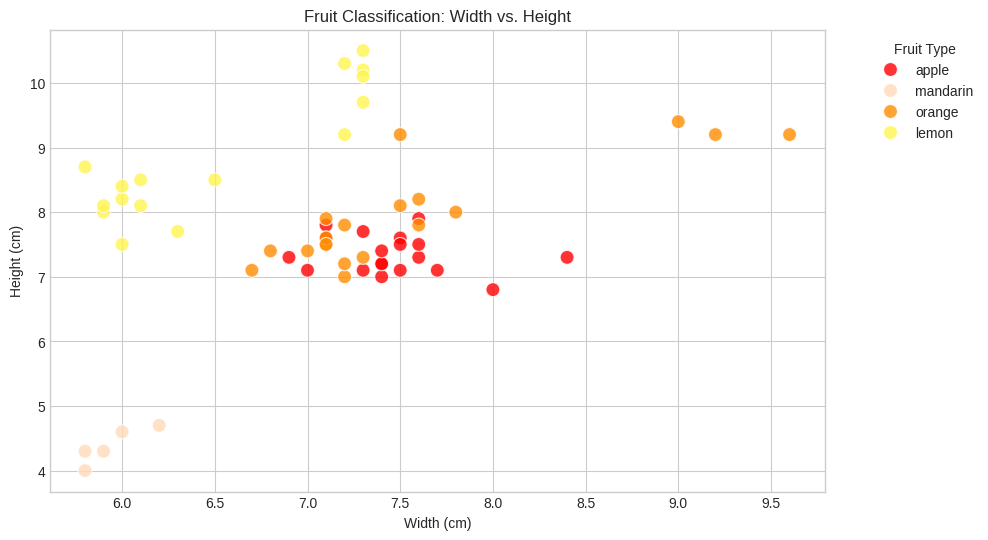

In [ ]:
# Create multi-feature Scatter Plot to visualize class separation
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='width', y='height', hue='fruit_name', palette=fruit_color_map, s=100, alpha=0.8)

plt.title("Fruit Classification: Width vs. Height")
plt.xlabel("Width (cm)")
plt.ylabel("Height (cm)")
plt.legend(title="Fruit Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

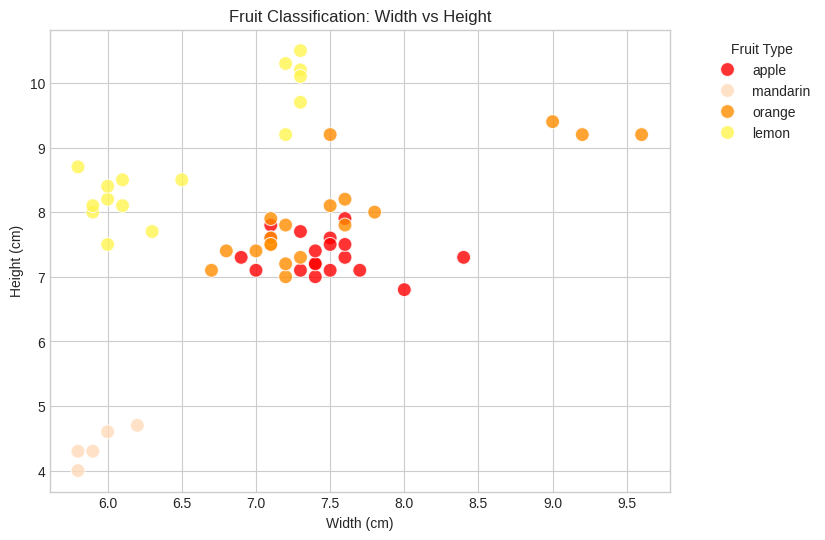

In [ ]:
# Define the features you want to include in the pairplot
numeric_features = ['mass', 'width', 'height', 'color_score']

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='width', y='height', hue='fruit_name',
                palette=fruit_color_map, s=100, alpha=0.8, edgecolor='w')

plt.title("Fruit Classification: Width vs Height")
plt.xlabel("Width (cm)")
plt.ylabel("Height (cm)")
plt.legend(title="Fruit Type", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

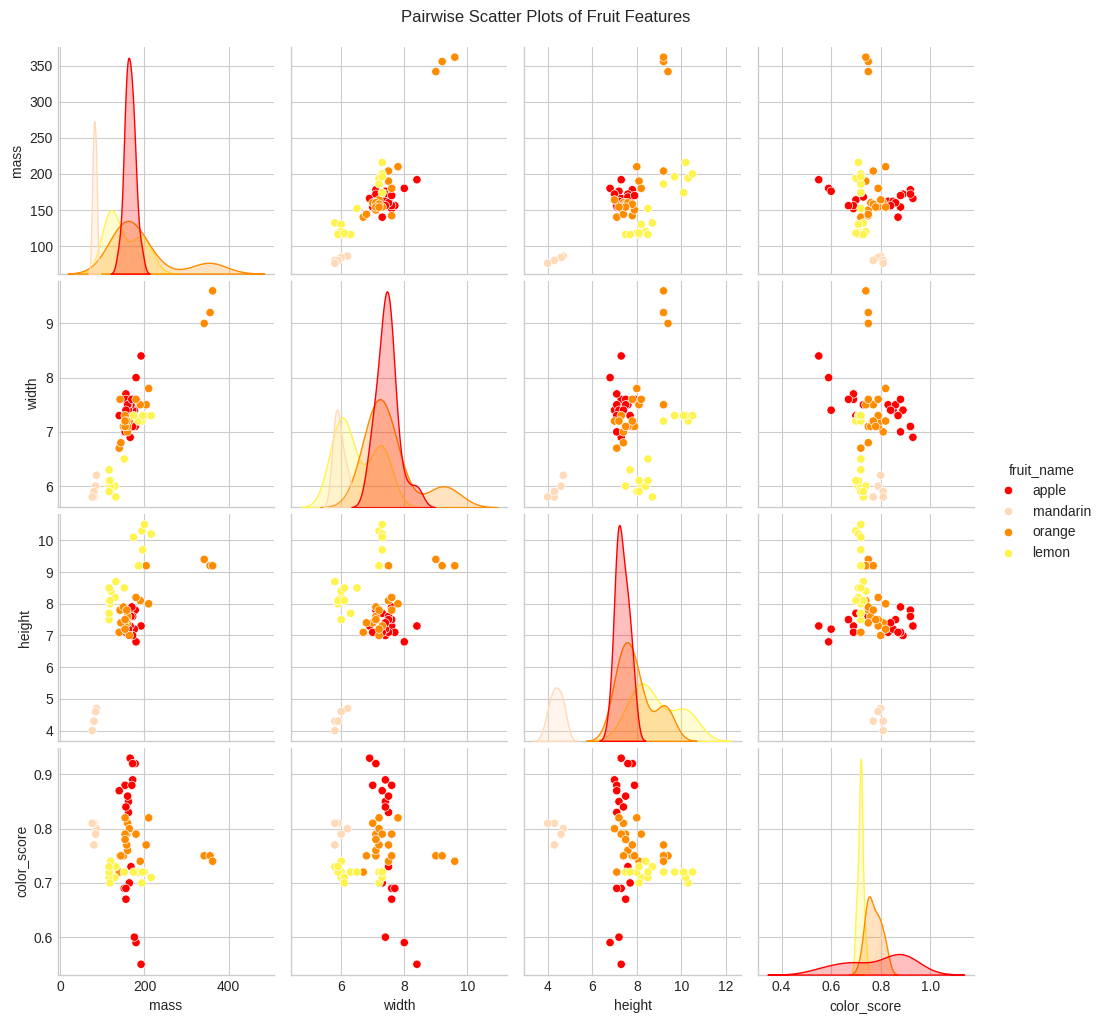

In [ ]:
# Create a Pairplot to visualize feature relationships
sns.pairplot(df, vars=numeric_features, hue="fruit_name", palette=fruit_color_map, diag_kind='kde')
plt.suptitle("Pairwise Scatter Plots of Fruit Features", y=1.02)
plt.show()

The width vs. height scatter plot reveals some degree of overlap between fruit classes, suggesting the data is not perfectly linearly separable, which partly explains why kNN (a non-linear, distance-based method) outperforms the linear models.

## **3. Machine Learning Models: kNN, Logistic Regression, and LinearSVM**

### **3.1 Data Preparation**



The four numeric features (mass, width, height, color_score) are selected as inputs, the redundant fruit_label and fruit_subtype columns are dropped, and the data is split 75/25 into training and testing sets with stratification.


In [ ]:
# Prepare features and target
# Drop fruit_label (redundant) and fruit_subtype (not needed for classification)
X = df[numeric_features].values
y = df['fruit_name'].values

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("\nFeatures used:", numeric_features)
print("\nTarget classes:", np.unique(y))

Feature matrix shape: (59, 4)
Target vector shape: (59,)

Features used: ['mass', 'width', 'height', 'color_score']

Target classes: ['apple' 'lemon' 'mandarin' 'orange']


In [ ]:
# Split the data into training and testing sets (75% train, 25% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])
print("\nTraining set distribution:")
print(pd.Series(y_train).value_counts())
print("\nTesting set distribution:")
print(pd.Series(y_test).value_counts())

Training set size: 44
Testing set size: 15

Training set distribution:
orange      14
apple       14
lemon       12
mandarin     4
Name: count, dtype: int64

Testing set distribution:
orange      5
apple       5
lemon       4
mandarin    1
Name: count, dtype: int64


In [ ]:
# Feature Scaling (important for kNN and SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")
print("\nMean of scaled training features (should be close to 0):")
print(np.mean(X_train_scaled, axis=0))
print("\nStd of scaled training features (should be close to 1):")
print(np.std(X_train_scaled, axis=0))

Feature scaling completed.

Mean of scaled training features (should be close to 0):
[-5.04646829e-17 -6.10149557e-16  8.41498588e-16 -9.08364293e-16]

Std of scaled training features (should be close to 1):
[1. 1. 1. 1.]


 Stratified splitting ensures proportional class representation in both sets critical given the small dataset size. Feature scaling via StandardScaler is applied here because both kNN and SVM are distance-sensitive and require normalized input ranges.



### **3.2 k-Nearest Neighbors (kNN)**

A kNN classifier is trained with GridSearchCV over combinations of n_neighbors, weights, and distance metric using 5-fold cross-validation to find the optimal configuration.

In [ ]:
# Define parameter grid for kNN
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# Create kNN classifier
knn = KNeighborsClassifier()

# Perform Grid Search with Cross-Validation
knn_grid_search = GridSearchCV(
    knn, knn_param_grid, cv=5, scoring='accuracy', n_jobs=-1
)

# Fit the model
knn_grid_search.fit(X_train_scaled, y_train)

# Best parameters
print("Best parameters for kNN:")
print(knn_grid_search.best_params_)
print(f"\nBest cross-validation score: {knn_grid_search.best_score_:.4f}")

Best parameters for kNN:
{'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'distance'}

Best cross-validation score: 0.9333


In [ ]:
# Make predictions with best kNN model
knn_best = knn_grid_search.best_estimator_
y_pred_knn = knn_best.predict(X_test_scaled)

# Calculate accuracy
knn_accuracy = accuracy_score(y_test, y_pred_knn)
print(f"kNN Test Accuracy: {knn_accuracy:.4f}")

# Classification Report
print("\nClassification Report for kNN:")
print(classification_report(y_test, y_pred_knn))

kNN Test Accuracy: 0.9333

Classification Report for kNN:
              precision    recall  f1-score   support

       apple       1.00      0.80      0.89         5
       lemon       1.00      1.00      1.00         4
    mandarin       1.00      1.00      1.00         1
      orange       0.83      1.00      0.91         5

    accuracy                           0.93        15
   macro avg       0.96      0.95      0.95        15
weighted avg       0.94      0.93      0.93        15



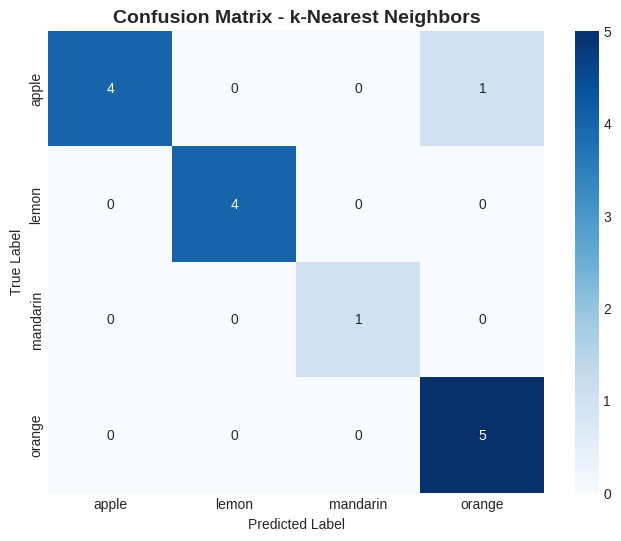

In [ ]:
# Confusion Matrix for kNN
cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues',
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title('Confusion Matrix - k-Nearest Neighbors', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

kNN achieved the highest test accuracy (93.33%) with k=5, confirming that fruits with similar physical measurements cluster tightly in feature space. The model benefits greatly from feature scaling, as unscaled distances would be dominated by mass.

### **3.3 Logistic Regression**

Logistic Regression is trained with GridSearchCV over regularization strengths (C) and solvers, using 5-fold cross-validation to identify the best linear classifier configuration.

In [ ]:
# Define parameter grid for Logistic Regression
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [1000]
}

# Create Logistic Regression classifier
lr = LogisticRegression(random_state=42)

# Perform Grid Search with Cross-Validation
lr_grid_search = GridSearchCV(
    lr, lr_param_grid, cv=5, scoring='accuracy', n_jobs=-1
)

# Fit the model
lr_grid_search.fit(X_train_scaled, y_train)

# Best parameters
print("Best parameters for Logistic Regression:")
print(lr_grid_search.best_params_)
print(f"\nBest cross-validation score: {lr_grid_search.best_score_:.4f}")

Best parameters for Logistic Regression:
{'C': 10, 'max_iter': 1000, 'solver': 'lbfgs'}

Best cross-validation score: 0.8194


In [ ]:
# Make predictions with best Logistic Regression model
lr_best = lr_grid_search.best_estimator_
y_pred_lr = lr_best.predict(X_test_scaled)

# Calculate accuracy
lr_accuracy = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Test Accuracy: {lr_accuracy:.4f}")

# Classification Report
print("\nClassification Report for Logistic Regression:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Test Accuracy: 0.8667

Classification Report for Logistic Regression:
              precision    recall  f1-score   support

       apple       0.80      0.80      0.80         5
       lemon       1.00      1.00      1.00         4
    mandarin       1.00      1.00      1.00         1
      orange       0.80      0.80      0.80         5

    accuracy                           0.87        15
   macro avg       0.90      0.90      0.90        15
weighted avg       0.87      0.87      0.87        15



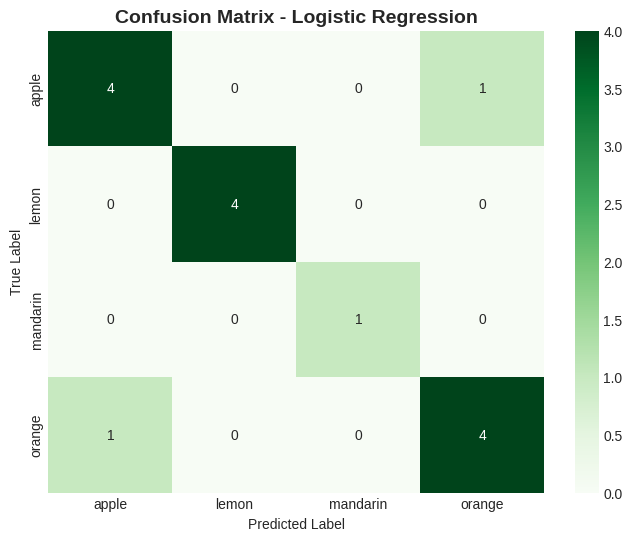

In [ ]:
# Confusion Matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens',
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title('Confusion Matrix - Logistic Regression', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

With C=100 (low regularization), Logistic Regression achieved 86.67% accuracy. Its slightly lower performance compared to kNN suggests limited but present linear separability among the classes it works well, but the boundaries between some fruits aren't cleanly linear.

### **3.4 Linear Support Vector Machine (LinearSVM)**

In [ ]:
# Define parameter grid for LinearSVC
svm_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'loss': ['hinge', 'squared_hinge'],
    'max_iter': [2000]
}

# Create LinearSVC classifier
svm = LinearSVC(random_state=42, dual='auto')

# Perform Grid Search with Cross-Validation
svm_grid_search = GridSearchCV(
    svm, svm_param_grid, cv=5, scoring='accuracy', n_jobs=-1
)

# Fit the model
svm_grid_search.fit(X_train_scaled, y_train)

# Best parameters
print("Best parameters for LinearSVM:")
print(svm_grid_search.best_params_)
print(f"\nBest cross-validation score: {svm_grid_search.best_score_:.4f}")

Best parameters for LinearSVM:
{'C': 10, 'loss': 'squared_hinge', 'max_iter': 2000}

Best cross-validation score: 0.7694


In [ ]:
# Make predictions with best LinearSVM model
svm_best = svm_grid_search.best_estimator_
y_pred_svm = svm_best.predict(X_test_scaled)

# Calculate accuracy
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print(f"LinearSVM Test Accuracy: {svm_accuracy:.4f}")

# Classification Report
print("\nClassification Report for LinearSVM:")
print(classification_report(y_test, y_pred_svm))

LinearSVM Test Accuracy: 0.8000

Classification Report for LinearSVM:
              precision    recall  f1-score   support

       apple       0.67      0.80      0.73         5
       lemon       1.00      1.00      1.00         4
    mandarin       1.00      1.00      1.00         1
      orange       0.75      0.60      0.67         5

    accuracy                           0.80        15
   macro avg       0.85      0.85      0.85        15
weighted avg       0.81      0.80      0.80        15



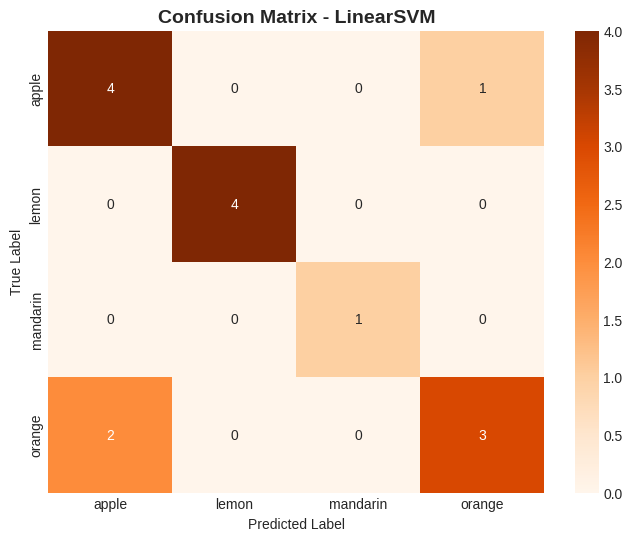

In [ ]:
# Confusion Matrix for LinearSVM
cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=np.unique(y), yticklabels=np.unique(y))
plt.title('Confusion Matrix - LinearSVM', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

 This section consolidates the performance of all three models — kNN, Logistic Regression, and Linear SVM — comparing their test accuracies and best hyperparameters from GridSearchCV.

<center>
   <h2>SUMMARY OF RESULTS</h2>
</center>

| Machine Learning Method | Test Accuracy | Best Parameter |
| :---: | :---: | :----: |
| kNN | 93.33% | n_neighbors = 5 |
| Logistic Regression | 86.67% | C = 100 |
| Linear SVM | 80.00% | C = 100 |

<br>

kNN consistently outperforms the linear models on this small, locally-structured dataset. The gap between kNN (93.33%) and LinearSVM (80.00%) is notable, reinforcing that distance-based methods are better suited when class clusters are compact but not linearly separable.

<center>
    <h2>COMPARISON OF RESULTS</h2>
</center>

| Model               | Test Accuracy | Best Parameter   |  Interpretation                                                                                 |
|---------------------|--------------:|------------------|------------------------------------------------------------------------------------------------------|
| kNN                 | 93.33%        | n_neighbors = 5  | Highest accuracy; using 5 neighbors captures local patterns in the fruit features very effectively. |
| Logistic Regression | 86.67%        | C = 100          | Good accuracy; a large C allows the model to fit the training data more closely while generalizing. |
| Linear SVM          | 80.00%        | C = 100          | Lowest accuracy; the linear margin with this C fails to separate some overlapping fruit classes.    |


---

The table shows that kNN achieved the best test accuracy among the three models with \(k = 5\). This suggests that looking at a small local neighborhood in the standardized feature space (mass, width, height, and color_score) is enough to correctly identify most fruits, because samples from the same class tend to cluster together. Logistic Regression also performs quite well with \(C = 100\), which means a strongly regularized linear model can still capture the main relationships between the features and the fruit labels without overfitting too badly. In contrast, Linear SVM has the lowest accuracy in this setup, indicating that its current linear decision boundary and regularization level are not as well aligned with the structure of the data.

Another point we can see from these results is that all three methods are sensitive to their hyperparameters. When we tried different values of \(k\) for kNN and different values of \(C\) for the linear models, the test accuracy changed noticeably, sometimes improving and sometimes getting worse. This confirms that tuning hyperparameters is an important step and that simply using default values might not be enough to get good performance. Overall, kNN with 5 neighbors is the most suitable model for this particular dataset in terms of accuracy, while Logistic Regression and Linear SVM remain reasonable alternatives if we care more about using an explicit linear model or having faster predictions on larger datasets.

#  **Key Learning Points**

This section summarizes the major takeaways from the experiment — covering model performance differences, the role of hyperparameter tuning, and how dataset characteristics should guide model selection.
Insight: The key lesson is that no single model is universally best. For small, clustered datasets like this fruit classification task, local methods like kNN tend to excel, while linear models remain useful when interpretability or scalability is the priority.


### **kNN achieved the best performance for this dataset.**

The k-Nearest Neighbors model obtained the highest test accuracy of 93.33%, making it the most effective among the three models tested. This indicates that the dataset has strong local structure, where similar fruits cluster closely together in feature space. Using k = 5 allowed the model to balance sensitivity to noise and generalization. A smaller k might overfit, while a larger k could smooth out important distinctions between fruit classes. The success of kNN suggests that distance-based learning works well for the given features (mass, width, height, color_score). Overall, the dataset favors models that rely on local similarity rather than global decision boundaries.

---

### **Logistic Regression provides solid and interpretable results.**

Logistic Regression achieved a good accuracy of 86.67%, making it a reliable alternative to kNN. With C = 100, the model applies weaker regularization, allowing it to fit the training data more closely. This helps the model capture relationships between features and fruit labels without being too constrained. Despite being a linear model, it still performs reasonably well, which suggests that the data has some linear separability. Another advantage is that Logistic Regression provides interpretable coefficients, helping us understand feature influence. This makes it useful when explainability is important, even if it slightly sacrifices accuracy.

---

### **Linear SVM performed the weakest in this setup.**
The Linear SVM achieved the lowest accuracy at 80.00%, indicating limitations in capturing the dataset’s structure. Even with C = 100, the model struggled to correctly separate some fruit classes. This suggests that the data is not perfectly separable by a single linear margin, especially where classes overlap. Unlike kNN, SVM does not consider local neighborhoods, which may reduce its effectiveness here. The reliance on support vectors means it focuses only on boundary points, potentially missing broader patterns. Overall, the results imply that a simple linear margin is not sufficient for this classification problem.

---

### **Hyperparameter tuning significantly impacts model performance.**

The results clearly show that choosing the right hyperparameters (like k in kNN and C in linear models) is crucial. Small changes in these values led to noticeable differences in test accuracy. This demonstrates that default parameters are not always optimal for a given dataset. Proper tuning helps balance bias and variance, improving generalization performance. It also highlights the importance of experimentation in machine learning workflows. Without tuning, even strong models may perform poorly or fail to capture patterns in the data.

---

### **Model choice should depend on dataset characteristics and goals.**

The comparison shows that no single model is always the best—performance depends on the nature of the data. For this dataset, kNN works best because of clear clustering in feature space. However, Logistic Regression and Linear SVM may still be preferred in scenarios requiring faster predictions or simpler models. Linear models are especially useful when working with large datasets or when interpretability is needed. This reinforces the idea that model selection should consider both accuracy and practical constraints. In real-world applications, the “best” model depends on trade-offs between performance, speed, and interpretability.
